In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
SPLIT     = 'test'
_MODELS   = CONFIGS['experiments']

MODELDICT = {
    'pod_bl':      {'label':_MODELS['pod']['runs']['pod_bl'].get('description','POD-BL'),                                        'color':'k'},
    'nn_bl':       {'label':_MODELS['nn']['runs']['nn_bl'].get('description','NN-BL'),                                           'color':'#fa862d'},
    'nn_full':     {'label':_MODELS['nn']['runs']['nn_full'].get('description','NN-FULL'),                                       'color':'#1b2c63'},
    'nn_nonparam': {'label':_MODELS['nn']['runs']['nn_nonparam'].get('description','NN-NONPARAM'),                               'color':'#245ba7'},
    'nn_gauss':    {'label':_MODELS['nn']['runs']['nn_gauss'].get('description','NN-GAUSS'),                                     'color':'#5ca7db'},
    'sr_bl':       {'label':_MODELS['sr']['optimizedeqs']['sr_bl'].get('description','SR-BL'),                                   'color':'#c41d24'},
    'sr_full':     {'label':_MODELS['sr']['optimizedeqs'].get('sr_full',{}).get('description','SR-FULL'),                        'color':'#a3ddf7'},
}

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for name in MODELDICT:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        print(f'Missing: {name}')
        continue
    with xr.open_dataset(filepath) as ds:
        pred = ds.tp.load()
    if 'seed' in pred.dims:
        pred = pred.mean('seed')
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    ytrue,ypred   = xr.align(truetp,pred,join='inner')
    results[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Loaded {len(results)}/{len(MODELDICT)} models')

Missing: sr_full
Loaded 6/7 models


## Approach 1: Exceedance probability curves

Plot the empirical survival function P(X > x) on a log–log scale for each model alongside the observed distribution. This directly reveals whether a model captures the heavy tail of the rainfall distribution.

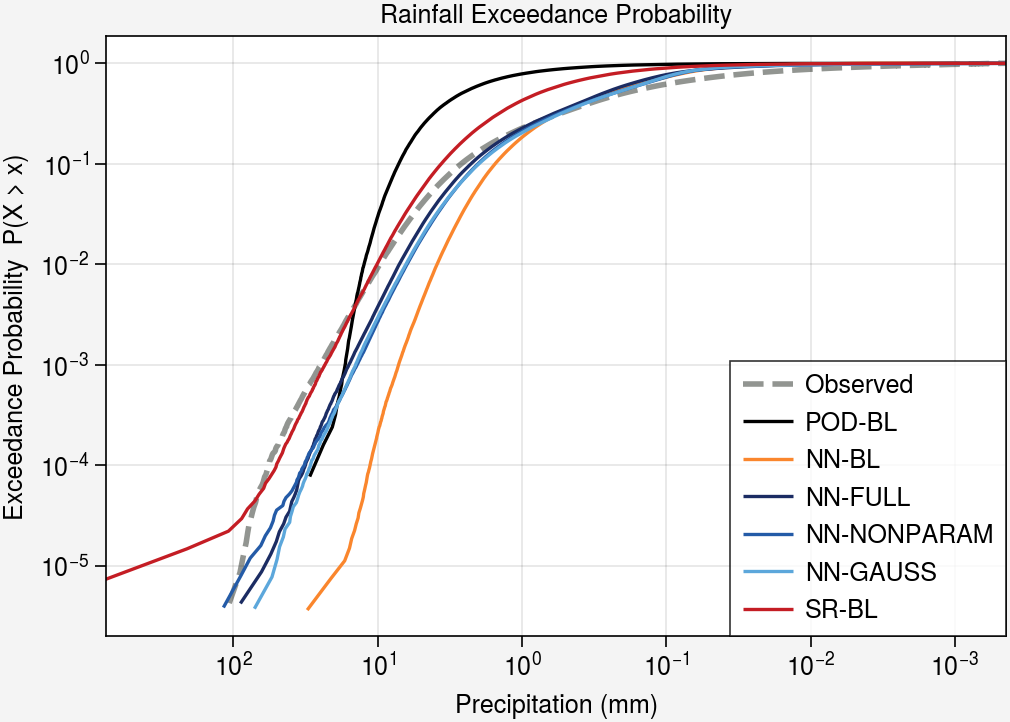

In [5]:
def exceedance_curve(arr,subsample=5):
    '''Return (sorted_values_desc, exceedance_probs) for positive finite values.'''
    flat = arr.ravel()
    flat = flat[np.isfinite(flat) & (flat > 0)]
    flat = np.sort(flat)[::-1][::subsample]
    prob = np.arange(1,len(flat)+1) / len(flat)
    return flat,prob

ytrue_ref = next(iter(results.values()))[0]
obs_x,obs_p = exceedance_curve(ytrue_ref.values)

fig,ax = pplt.subplots(refwidth=4.5,refheight=3)
ax.plot(obs_x,obs_p,color='gray',lw=2,linestyle='--',label='Observed',zorder=0)
for name,info in MODELDICT.items():
    if name not in results:
        continue
    pred_x,pred_p = exceedance_curve(results[name][1].values)
    ax.plot(pred_x,pred_p,color=info['color'],lw=1.2,label=info['label'])
ax.format(
    xlabel='Precipitation (mm)',
    ylabel='Exceedance Probability  P(X > x)',
    xscale='log',yscale='log',xformatter='log',yformatter='log',
    grid=True,title='Rainfall Exceedance Probability')
ax.legend(loc='lr',ncols=1)
pplt.show()
# fig.save('../figs/fig_S_extremes_exceedance.jpg')

## Approach 3: Spatial maps of 95th-percentile bias

Compute the local 95th percentile at each grid point for the observations and each model, then map the bias (model − observed). This reveals where in the domain each model tends to over- or under-predict heavy rainfall events.

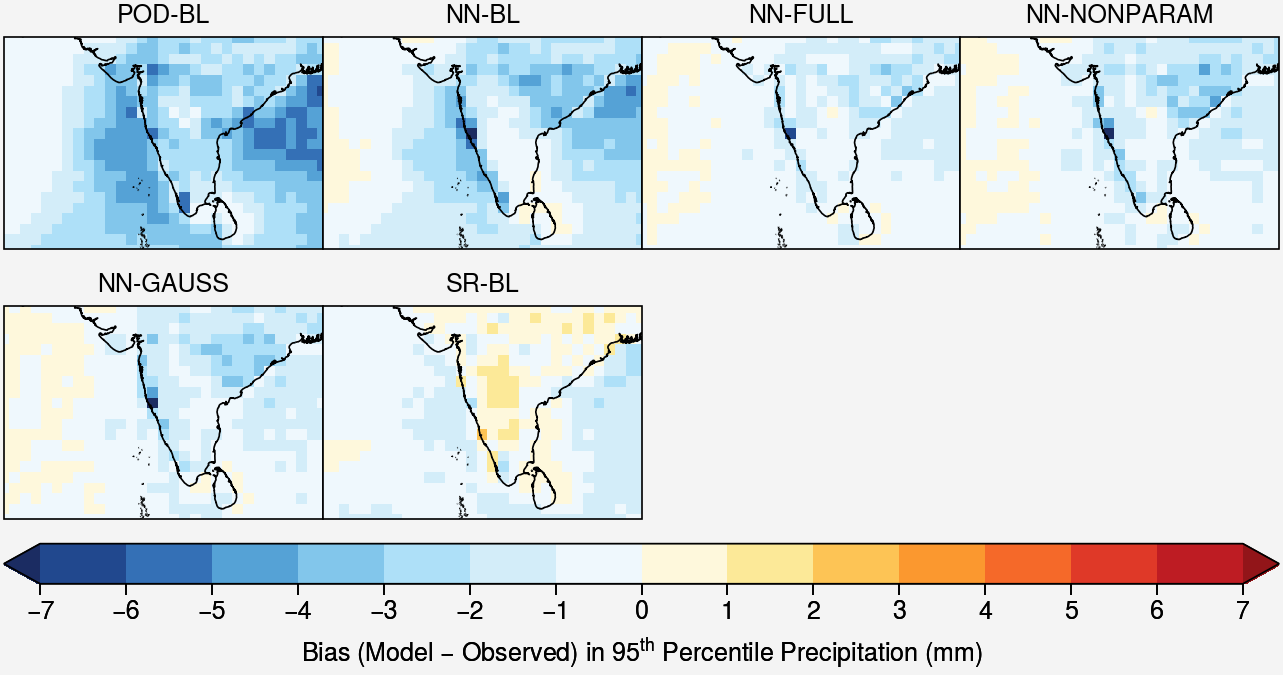

In [6]:
ytrue_ref = next(iter(results.values()))[0]
obs_p95   = ytrue_ref.quantile(0.95,dim='time',skipna=True)

names_ordered = [n for n in MODELDICT if n in results]
n     = len(names_ordered)
ncols = 4
nrows = int(np.ceil(n/ncols))

# Compute bias range for symmetric colorbar
biases = []
for name in names_ordered:
    _,ypred  = results[name]
    pred_p95 = ypred.quantile(0.95,dim='time',skipna=True)
    biases.append(pred_p95 - obs_p95)
vmax = max(float(abs(b).max()) for b in biases)

fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,proj='cyl',figwidth=6.5,share=False,wspace=0)
axs.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,latlines=5,lonlines=5,grid=False)
m = None
for ax,name,bias in zip(axs,names_ordered,biases):
    m = ax.pcolormesh(bias.lon,bias.lat,bias,
                      cmap='ColdHot',vmin=-vmax,vmax=vmax,levels=16,extend='both')
    ax.format(title=MODELDICT[name]['label'])
for ax in axs[n:]:
    ax.set_visible(False)
fig.colorbar(m,loc='b',label='Bias (Model $-$ Observed) in 95$^{th}$ Percentile Precipitation (mm)',ticks=1)
pplt.show()
# fig.save('../figs/fig_S_extremes_p95_bias.jpg')